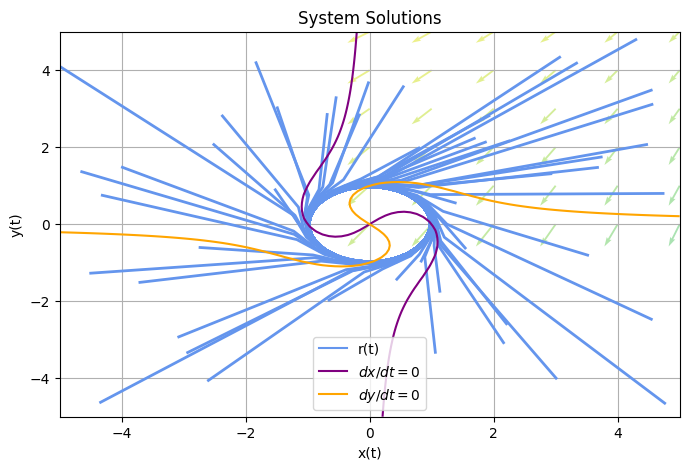

In [98]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ODE system in x, y
def ode_system(t, XY):
  x, y = XY
  xdot = -y+x*(1-x**2-y**2)
  ydot = x+y*(1-x**2-y**2)
  return [xdot, ydot]

# list of random x and y initial conditions
initial_conditions =  [(np.random.uniform(-5,5), np.random.uniform(-5,5))
                        for _ in range(50)]

t_0 = 0
t_f = 500
times = np.linspace(t_0, t_f, 1000)  # Points where solution is recorded

# numerically solve system
solutions = []
for ic in initial_conditions:
  sol = solve_ivp(ode_system, t_span = (t_0, t_f), y0=ic, t_eval = times, vectorized = True)
  solutions.append(sol)

# create grid of points for vector field and nullcines
x_range = np.linspace(-5, 5, 100)
y_range = np.linspace(-5, 5, 100)
X,Y = np.meshgrid(x_range, y_range)
DX, DY = ode_system(0, [X,Y])

# plot results
plt.figure(figsize=(8, 5))
for solution in solutions:
  plt.plot(solution.y[0], solution.y[1], linewidth=2, color = "cornflowerblue")
plt.plot([], [], color = "cornflowerblue", label = "r(t)")
# plot nullclines
plt.contour(X, Y, DX, levels=[0], colors = "purple")
plt.contour(X, Y, DY, levels=[0], colors = "orange")
plt.plot([], [], color = "purple", label = "$dx/dt=0$")
plt.plot([], [], color = "orange", label = "$dy/dt=0$")

norm = np.hypot(DX, DY)
norm[norm==0] = 1
plt.quiver(X[::5, ::5], Y[::5, ::5],
           DX[::5, ::5]/norm[::5, ::5],
           alpha = 0.5)

plt.xlabel('x(t)')
plt.xlim(-5,5)
plt.ylabel('y(t)')
plt.ylim(-5,5)

plt.title('System Solutions')
plt.legend()
plt.grid(True)
plt.show()

